In [537]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [538]:
df = pd.read_csv('500_Person_Gender_Height_Weight_Index.csv')

In [539]:
df.head()

,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4
3,Female,195,104,3
4,Male,149,61,3


In [540]:
df

,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4
3,Female,195,104,3
4,Male,149,61,3
...,...,...,...,...
495,Female,150,153,5
496,Female,184,121,4
497,Female,141,136,5
498,Male,150,95,5


In [541]:
df.shape

(500, 4)

In [542]:
df.describe()

,Height,Weight,Index
count,500.000000,500.000000,500.000000
mean,169.944000,106.000000,3.748000
std,16.375261,32.382607,1.355053
min,140.000000,50.000000,0.000000
25%,156.000000,80.000000,3.000000
50%,170.500000,106.000000,4.000000
75%,184.000000,136.000000,5.000000
max,199.000000,160.000000,5.000000


In [543]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Gender  500 non-null    object
 1   Height  500 non-null    int64 
 2   Weight  500 non-null    int64 
 3   Index   500 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 15.8+ KB


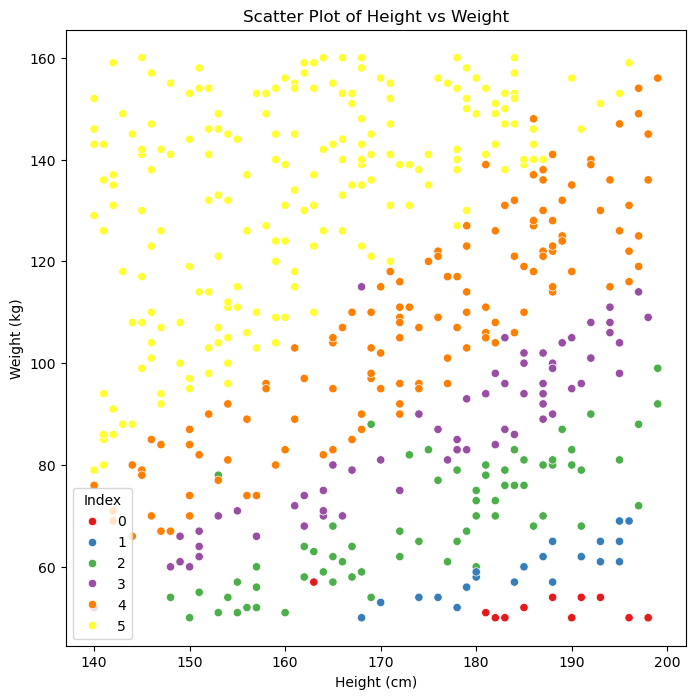

In [544]:
# Vẽ biểu đồ phân phối của chiều cao và cân nặng
plt.figure(figsize=(8, 8))
sns.scatterplot(x='Height', y='Weight', hue='Index', data=df, palette='Set1')
plt.title('Scatter Plot of Height vs Weight')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.legend(title='Index')
plt.show()

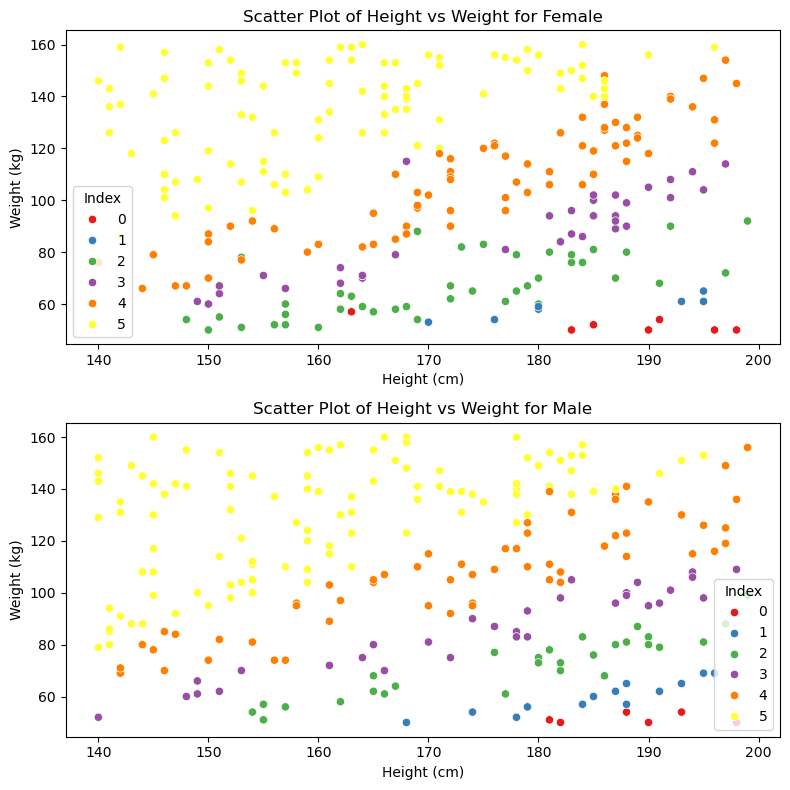

In [545]:
# Scatter plots of Height vs Weight by gender
fig, axes = plt.subplots(2, 1, figsize=(8, 8))

sns.scatterplot( x='Height', y='Weight', hue='Index', data=df[df['Gender'] == 'Female'], palette='Set1', ax=axes[0])
axes[0].set_title('Scatter Plot of Height vs Weight for Female')
axes[0].set_xlabel('Height (cm)')
axes[0].set_ylabel('Weight (kg)')
axes[0].legend(title='Index')

sns.scatterplot(x='Height', y='Weight', hue='Index', data=df[df['Gender'] == 'Male'], palette='Set1', ax=axes[1])
axes[1].set_title('Scatter Plot of Height vs Weight for Male')
axes[1].set_xlabel('Height (cm)')
axes[1].set_ylabel('Weight (kg)')
axes[1].legend(title='Index')

plt.tight_layout()
plt.show()



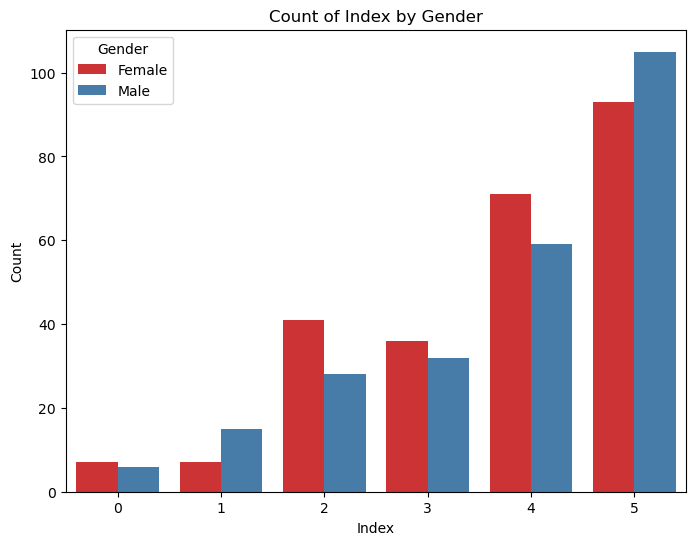

In [546]:
#biểu đồ count các Index theo giới tính
plt.figure(figsize=(8, 6))
sns.countplot(x='Index', hue='Gender', data=df, palette='Set1')
plt.title('Count of Index by Gender')
plt.xlabel('Index')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.show()

### Dựa vào phân bố dữ liệu từ biểu đồ Scatter và biểu dồ Index theo Gender, ta có thể thấy phần lớn tập dữ liệu là các index 4 và 5, đây là các nhóm 2 trạng thái Obesity và Extreme Obesity, ngược lại đối với nhóm index 0 1 là Extremely WeakWeak thì rất ít dữ liệu, nhóm 2 3 là Normal và Overweight thì có lượng tương đương nhau => Từ lượng dữ liệu và phân bố các classes, nhóm chúng lại thành 3 nhóm như sau:
- Nhóm 1 - Gầy: Các index 0 1
- Nhóm 2 - Bình thường: Các index 2 3 
- Nhóm 3 - Mập: Các index 4 5 

In [547]:
#Chuẩn hóa dữ liệu Gender 
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df

,Gender,Height,Weight,Index
0,0,174,96,4
1,0,189,87,2
2,1,185,110,4
3,1,195,104,3
4,0,149,61,3
...,...,...,...,...
495,1,150,153,5
496,1,184,121,4
497,1,141,136,5
498,0,150,95,5


In [548]:
#gộp nhóm Index thành 3 nhóm: 0 1 = Gầy (1 ), 2 3 = Bình thường ( 2 ), Mập (3)  = 4 5 
mapping_dict = {
    0: 'Gầy', 
    1: 'Gầy',
    2: 'Bình thường', 
    3: 'Bình thường',
    4: 'Mập', 
    5: 'Mập'
}
df['Index'] = df['Index'].map(mapping_dict)
df

,Gender,Height,Weight,Index
0,0,174,96,Mập
1,0,189,87,Bình thường
2,1,185,110,Mập
3,1,195,104,Bình thường
4,0,149,61,Bình thường
...,...,...,...,...
495,1,150,153,Mập
496,1,184,121,Mập
497,1,141,136,Mập
498,0,150,95,Mập


In [ ]:
df['Index'] = df['Index'].map({'Gầy': 0, 'Bình thường': 1, 'Mập': 2})
# tính toán và thêm cột BMI: BMI = Weight (kg) / Height (m)^2
df['BMI'] = df['Weight'] / ((df['Height'] / 100) ** 2)
df

,Gender,Height,Weight,Index,BMI
0,0,174,96,2,31.708284
1,0,189,87,1,24.355421
2,1,185,110,2,32.140248
3,1,195,104,1,27.350427
4,0,149,61,1,27.476240
...,...,...,...,...,...
495,1,150,153,2,68.000000
496,1,184,121,2,35.739603
497,1,141,136,2,68.407022
498,0,150,95,2,42.222222


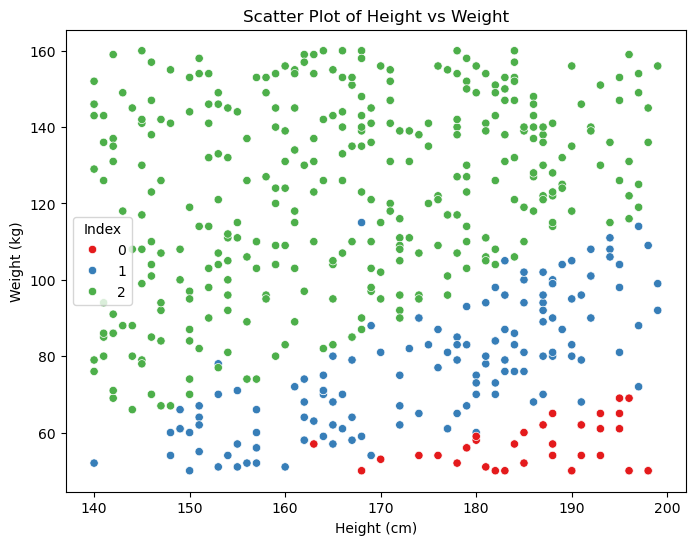

In [550]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Height', y='Weight', hue='Index', data=df, palette='Set1')
plt.title('Scatter Plot of Height vs Weight')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.legend(title='Index')
plt.show()

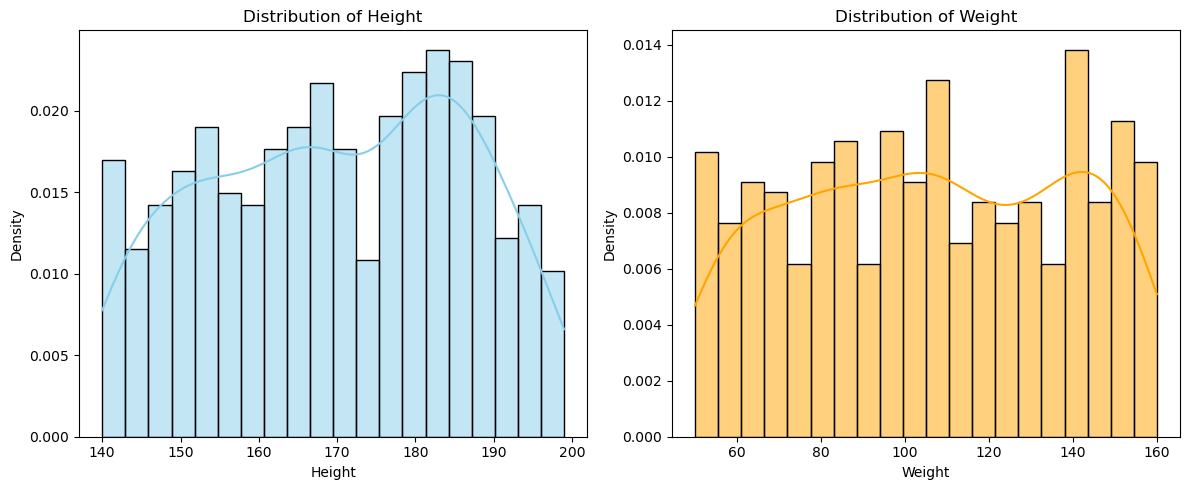

In [551]:
#phân phối của các biến liên tục
ax, fg = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['Height'],bins=20, kde=True, stat='density', color='skyblue', ax=fg[0])
fg[0].set_title('Distribution of Height')
sns.histplot(df['Weight'], bins=20, kde=True, stat='density', color='orange', ax=fg[1])
fg[1].set_title('Distribution of Weight')
plt.tight_layout()
plt.show()

In [552]:
df.describe()

,Gender,Height,Weight,Index,BMI
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.510000,169.944000,106.000000,1.586000,37.765284
std,0.500401,16.375261,32.382607,0.619169,13.965620
min,0.000000,140.000000,50.000000,0.000000,12.753801
25%,0.000000,156.000000,80.000000,1.000000,27.169353
50%,1.000000,170.500000,106.000000,2.000000,36.956941
75%,1.000000,184.000000,136.000000,2.000000,46.390467
max,1.000000,199.000000,160.000000,2.000000,78.853402


### với số lượng dữ liệu chỉ 500 dòng và không có phân phối đẹp, đồng thời các biểu đồ cũng cho ta thấy rõ rằng đây là 1 tập dữ liệu imbalance dataset ( tập dữ liệu mất cân bằng )
=>  Vì vậy áp dụng các kỹ thuật xử lý dự liệu như Smote hoặc RandamOversampling để cân bằng dữ liệu

In [554]:
X = df[['Gender', 'Height', 'Weight', 'BMI']].values
y = df['Index'].values

In [555]:
from sklearn.model_selection import train_test_split

In [556]:
# Sử dụng stratify=y để đảm bảo tỷ lệ các lớp Index trong tập Train và Test là tương đương nhau
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [557]:
X_train

array([[  1.        , 176.        , 121.        ,  39.0625    ],
       [  1.        , 172.        ,  90.        ,  30.42184965],
       [  1.        , 156.        , 126.        ,  51.77514793],
       ...,
       [  1.        , 153.        , 149.        ,  63.65073262],
       [  0.        , 170.        ,  81.        ,  28.02768166],
       [  0.        , 159.        , 104.        ,  41.13761323]])

In [558]:
X_train.shape

(400, 4)

In [553]:
#áp dụng smote để cân bằng dữ liệu
from imblearn.over_sampling import SMOTE

In [559]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [560]:
X_train_resampled.shape

(786, 4)

In [561]:
X_test_sklearn = X_test.copy()

Thuật toán Gaussian Naive Bayes from scratch
$$P(x_i | y) = \frac{1}{\sqrt{2\pi\sigma_y^2}} \exp\left(-\frac{(x_i - \mu_y)^2}{2\sigma_y^2}\right)$$

In [562]:
def train_gnb(X,y):
    classes = np.unique(y)
    models_parameters = {}
    
    for c in classes:
        X_c = X[y == c]
        mean = X_c.mean(axis=0) # tính trung bình 
        var = X_c.var(axis=0) + 1e-6  # tính phương sai 
        prior = X_c.shape[0] / X.shape[0] # tính tiên nghiệm ở lớp C
        models_parameters[c] = {'mean': mean, 'var': var, 'prior': prior}
        #print(f"Class {c}: mean={mean}, var={var}, prior={prior}")
    return classes, models_parameters

In [563]:
classes, model_params = train_gnb(X_train_resampled, y_train_resampled)

### Sau khi tính toán được trung bình và phương sai, tiên nghiệm của các class, ta tiến hình tính toán Likelihood bằng hàm mật độ xác suất
$$p(x|y = c) = \prod_{j=1}^{D} \mathcal{N}(x_j|\mu_{jc}, \sigma_{jc}^2)$$
- $x$: Là một vector chứa toàn bộ thông tin của đối tượng mới (VD: $x = [172 \text{ cm}, 68 \text{ kg}]$).
- $y = c$: Lớp mà ta đang giả định (VD: $c = \text{Nam}$).

In [564]:
def cal_log_pdf(X, mean, var):
    # Sử dụng hàm tính trực tiếp bằng log mật độ xác suất thay vì tính PDF rồi lấy log
    return -0.5 * np.log(2 * np.pi * var) - 0.5 * ((X - mean)**2 / var)

In [565]:
def predict_single_point(X, classes, model_params):
    posteriors = []
    
    for c in classes:
        mean = model_params[c]['mean']
        var = model_params[c]['var']
        prior_log = np.log(model_params[c]['prior'])
        
        # tính tổng bằng cách gọi hàm cal_log_pdf
        likelihood_log = np.sum(cal_log_pdf(X, mean, var)) 
        
        #tính toán hậu nghiệm
        posterior_log = prior_log + likelihood_log
        posteriors.append(posterior_log)
        #print(f"Class {c}: Prior Log={prior_log:.4f}, Likelihood Log={likelihood_log:.4f}, Posterior Log={posterior_log:.4f}")
    #trả về lớp có hậu nghiệm cao nhất 
    return classes[np.argmax(posteriors)]

In [566]:
#dự đoán cho toàn tập dữ liệu
def predict(X, classes, model_params):
    y_pred = np.array([predict_single_point(x, classes, model_params) for x in X])
    return np.array(y_pred)

In [567]:
y_pred = predict(X_test, classes, model_params)

In [568]:
y_pred

array([1, 2, 2, 0, 1, 2, 2, 2, 1, 1, 2, 2, 1, 2, 1, 2, 2, 2, 1, 2, 2, 2,
       1, 2, 1, 1, 2, 2, 2, 2, 1, 2, 2, 0, 2, 1, 2, 1, 2, 2, 2, 1, 2, 1,
       2, 2, 1, 2, 0, 2, 1, 2, 2, 1, 0, 1, 2, 2, 2, 2, 0, 2, 2, 2, 2, 1,
       2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 0, 1, 2, 1, 2, 2, 2, 0, 2, 2,
       1, 1, 1, 1, 2, 2, 2, 2, 2, 1, 2, 0], dtype=int64)

In [569]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [570]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.9600


In [571]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.93         7
           1       0.90      0.96      0.93        27
           2       1.00      0.95      0.98        66

    accuracy                           0.96       100
   macro avg       0.92      0.97      0.95       100
weighted avg       0.96      0.96      0.96       100



Confusion Matrix:


Text(0.5, 1.0, 'Confusion Matrix')

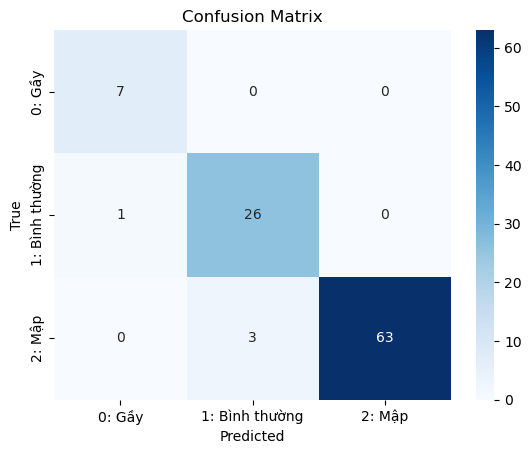

In [572]:
cfs_mt = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
label = ['0: Gầy', '1: Bình thường', '2: Mập']
sns.heatmap(cfs_mt, annot=True, fmt='d', cmap='Blues', xticklabels=label, yticklabels=label)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

In [573]:
gender = 0 # Nam
h = 160
w = 50
bmi = w / ((h / 100) ** 2)

X_testing = np.array([[gender, h, w, bmi]]) # Giới tính, Chiều cao, Cân nặng, BMI
predict_single_point(X_testing[0], classes, model_params)

1

In [574]:
gender1 = 0 # Nam
h1 = 170
w = 60
bmi = w / ((h1 / 100) ** 2)
X_testing = np.array([[gender1, h1, w, bmi]]) # Giới tính, Chiều cao, Cân nặng, BMI
predict_single_point(X_testing[0], classes, model_params)

1

### Thử nghiệm lại trên Gaussian Naive Bayes của thư viện Sklearn

In [575]:
from sklearn.naive_bayes import GaussianNB

In [576]:
model = GaussianNB()
model.fit(X_train_resampled, y_train_resampled)

GaussianNB()

In [577]:
import pickle
with open('gnb_model.pkl', 'wb') as file:
    pickle.dump(model, file)

In [578]:
# accuracy của sklearn
y_pred_sklearn = model.predict(X_test_sklearn)
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)

In [579]:
acc_sklearn

0.96

Confusion Matrix (sklearn):


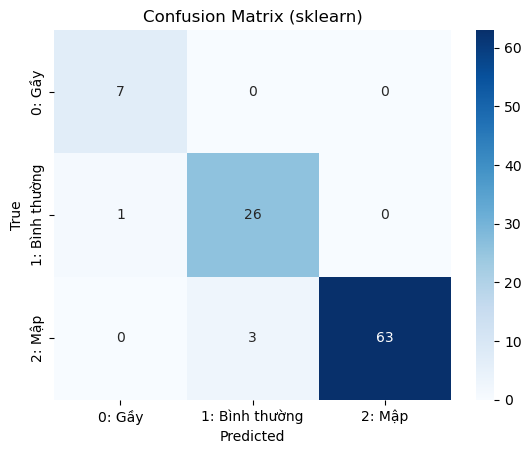

In [580]:
# confusion matrix mô hình của sklearn
cfs_mt_sklearn = confusion_matrix(y_test, y_pred_sklearn)
print("Confusion Matrix (sklearn):")   
label = ['0: Gầy', '1: Bình thường', '2: Mập']
sns.heatmap(cfs_mt_sklearn, annot=True, fmt='d', cmap='Blues', xticklabels=label, yticklabels=label)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (sklearn)')
plt.show()